<a href="https://colab.research.google.com/github/msemihyasa/Semih/blob/main/244329037_Yapay_Zeka_Prensipleri_Final.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

**Üsküdar Üniversitesi**


Yapay Zeka Mühendisliği Yüksek Lisans

**Yapay Zekanın Prensipleri Final Sınavı**

Akıllı Destek Masası (IT Help Desk) Otomasyonu ve Sınıflandırma

Dr. Öğr. Üyesi Nuri Bingöl



---


Hazırlayan: 244329037 Mehmet Semih Yaşa



-- Veri Yükleme --

In [4]:
from google.colab import drive
import pandas as pd
import re

drive.mount('/content/drive')
file_path = '/content/drive/MyDrive/Colab Notebooks/v1_f_IT_Department_Sorunlar_.xlsx'
df = pd.read_excel(file_path)

print(df.head())

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
     id  subject                                               body  label
0   698      NaN  Merhaba,\n\nİK portalına ve ERP sistemine girm...    NaN
1  2435      NaN  Merhaba,\n\nİK portalına ve ERP sistemine girm...    NaN
2  1789      NaN  Selamlar,\n\nVPN'e bağlanmaya çalışırken sürek...    NaN
3  2045      NaN  Merhaba,\n\nSAP'a girmeye çalıştığımda sunucu ...    NaN
4   156      NaN  Selamlar,\n\nEkibe yeni bir arkadaşımız katıld...    NaN


**Regex ile Ön Sınıflandırma (Hata vs. İstek)**

In [5]:
import pandas as pd
import re

# 1. Regex Desenlerinin Tanımlanması
hata_pattern = re.compile(
    r"\b("
    r"sorun|problem|hata|arıza|çalışm(ı|i)yor|çök(üyor|tu)|don(du|uyor)|aksıyor|kesinti|yanıt vermiyor|"
    r"ulaşılam(ı|i)yor|erişem(iyor|iyorum)|bağlan(am|amıyor|amıyorum)|giremiyor|giremiyorum|yüklenmiyor|"
    r"kesinti|timeout|zaman aşımı|error|failed|failure|exception|bug|"
    r"sunucu(ya)?\s+ulaşılam(ı|i)yor|vpn\s+bağlantı\s+problem(i)?"
    r")\b",
    re.IGNORECASE
)

istek_pattern = re.compile(
    r"\b("
    r"talep|istek|rica|ekle(me|yin|yin)|eklen(me|sin)|tanımlayıp|kurulum|yükle(me|yin)|"
    r"oluştur(ma|un)|aç(ma|ın)|tanımla(ma|yın)|yetki|izin|erişim\s+talep(i)?|"
    r"mail\s+grubu\s+ekle(me)?|yeni\s+kullanıcı|yeni_başlayan|"
    r")\b",
    re.IGNORECASE
)

def label(metin):
    if pd.isna(metin):
        return "BELİRSİZ"

    metin = metin.lower() # standartlaştırma

    # Hata kontrolü
    if re.search(hata_pattern, metin):
        return "HATA"
    # İstek kontrolü
    elif re.search(istek_pattern, metin):
        return "İSTEK"
    else:
        return "BELİRSİZ"

# 2. Fonksiyonun Uygulanması
df['label'] = df['body'].apply(label)

# Sonuç kontrol
print("Sınıflandırma İstatistikleri:")
print(df['label'].value_counts())
print("\nÖrnek Sonuçlar:")
print(df[['id', 'label']].head())

Sınıflandırma İstatistikleri:
label
İSTEK    1514
HATA     1486
Name: count, dtype: int64

Örnek Sonuçlar:
     id  label
0   698   HATA
1  2435   HATA
2  1789   HATA
3  2045   HATA
4   156  İSTEK


**LLM Öncesi Regex ile Kategori Bulma**

In [6]:
Subject_PATTERNS = {
    "Kullanıcı Yönetimi": re.compile(
        r".*\b("
        r"mail\s+grubu|dağıtım\s+listesi|"
        r"gruba\s+ekle|liste(ye)?\s+ekle|"
        r"yeni\s+başlayan|yeni\s+personel|"
        r"kullanıcı\s+hesab\w*\s+oluştur|"
        r"hesap\s+oluştur|user\s+create"
        r")\b.*$",
        re.IGNORECASE | re.DOTALL
    ),

    "Raporlama": re.compile(
        r".*\b("
        r"raporlam\w*|rapor|report|dashboard|çıktı|excel\s+rapor|powerbi|export|csv"
        r")\b.*$",
        re.IGNORECASE | re.DOTALL
    ),

    "Bağlantı": re.compile(
        r"^(?!.*\b("
        r"rapor|raporlam\w*|dashboard|powerbi|"
        r"mail\s+grubu|dağıtım\s+listesi|"
        r"yeni\s+başlayan|yeni\s+personel|ekibe\s+yeni|"
        r"kullanıcı\s+hesab"
        r")\b)"
        r"(?=.*\b("
        r"vpn|wifi|lan|wan|dns|ip|ping|internet|network|ağ|"
        r"kesinti|kop\w*|tünel|proxy|gateway|dhcp"
        r")\b)"
        r".*\b("
        r"vpn|wifi|lan|wan|dns|ip|ping|internet|network|ağ|"
        r"kesinti|kop\w*|tünel|stabil|proxy|gateway|dhcp|"
        r"sunucuya\s+ulaşılam\w*|sunucu\s+yanıt\s+vermiyor|"
        r"dosya\s+sunucu\w*|file\s+server"
        r")\b.*$",
        re.IGNORECASE | re.DOTALL
    ),

    "Erişim": re.compile(
        r"^(?!.*\b("
        r"mail\s+grubu|dağıtım\s+listesi|"
        r"yeni\s+başlayan|yeni\s+personel|ekibe\s+yeni|"
        r"kullanıcı\s+hesab\w*\s+oluştur|hesap\s+oluştur|user\s+create|"
        r"gruba\s+ekle"
        r")\b)"
        r"(?=.*\b("
        r"yetki\w*|izin\w*|permission|rol\w*|"
        r"parol\w*|şifr\w*|password|"
        r"account|hesap|kilitli|unlock"
        r")\b)"
        r".*\b("
        r"yetki\w*|izin\w*|permission|rol\w*|"
        r"parol\w*|şifr\w*|password|auth|mfa|2fa|otp|"
        r"account|hesap|kilitli|unlock|giriş\s+yapam\w*"
        r")\b.*$",
        re.IGNORECASE | re.DOTALL
    ),

    "Yazılım": re.compile(
        r"^(?!.*\b("
        r"yetki\w*|izin\w*|parol\w*|şifr\w*|password|auth|mfa|2fa|otp"
        r")\b)"
        r"^(?!.*\b("
        r"vpn|internet|network|ağ|dns|ip|ping|wifi|lan|wan|kesinti|kop\w*"
        r")\b)"
        r"^(?!.*\b("
        r"rapor|raporlam\w*|dashboard|powerbi|excel\s+rapor|report|çıktı|export|csv"
        r")\b)"
        r".*\b("
        r"yazılım|uygulama|erp|sap|crm|ik\s+portal\w*|portal|program|"
        r"kurulum|yükle\w*|update|güncelle\w*|lisans|license|"
        r"çalışm\w*|crash|açılm\w*|don\w*|kilitlen\w*|"
        r"sistemden\s+at\w*|kapan\w*|uyarı\w*"
        r")\b.*$",
        re.IGNORECASE | re.DOTALL
    ),

    "Donanım": re.compile(
        r"^(?!.*\b("
        r"erp|sap|crm|portal|uygulama|program|update|güncelleme|lisans|"
        r"şifre|parola|yetki|izin|vpn|internet|network|ağ"
        r")\b)"
        r".*\b("
        r"donanım|pc|bilgisayar|laptop|notebook|"
        r"ekran|klavye|mouse|yazıcı|printer|toner|kartuş|"
        r"ram|disk|ssd|hdd"
        r")\b.*$",
        re.IGNORECASE | re.DOTALL
    ),
}

def regex_subject(text: str) -> str:
    t = (text or "").strip()
    hits = []
    for cat, pat in Subject_PATTERNS.items():
        if pat.search(t):
            hits.append(cat)
    if len(hits) == 1:
        return hits[0]
    return "BELIRSIZ"

df["regex_subject"] = df["body"].apply(regex_subject)

# LLM'e gidecekler: label BELIRSIZ veya regex_subject BELIRSIZ olanlar
df["needs_llm"] = (df["label"] == "BELİRSİZ") | (df["regex_subject"] == "BELIRSIZ")

# Sonuç kontrol
print("regex_subject:")
print(df['regex_subject'].value_counts())
print("\nÖrnek Sonuçlar:")
print(df[['id', 'regex_subject']].head())

regex_subject:
regex_subject
Erişim                1171
Bağlantı               892
Yazılım                594
Raporlama              223
BELIRSIZ                64
Kullanıcı Yönetimi      56
Name: count, dtype: int64

Örnek Sonuçlar:
     id regex_subject
0   698       Yazılım
1  2435       Yazılım
2  1789      Bağlantı
3  2045      Bağlantı
4   156      BELIRSIZ


LLM Maliyetini düşürmek için yapay zeka modeline göndermeden önce **Regex ile kategori bulma fonksiyonu**

Tek kategori yakalarsa: Bulunan kategori

Birden fazla yakalarsa: Belirsiz

Hiç yakalamazsa: Belirsiz

LLM'e gönderilecek veriler hem hata/istek sınıfı belirsiz hem de kategorisi belirsiz girişlerdir.

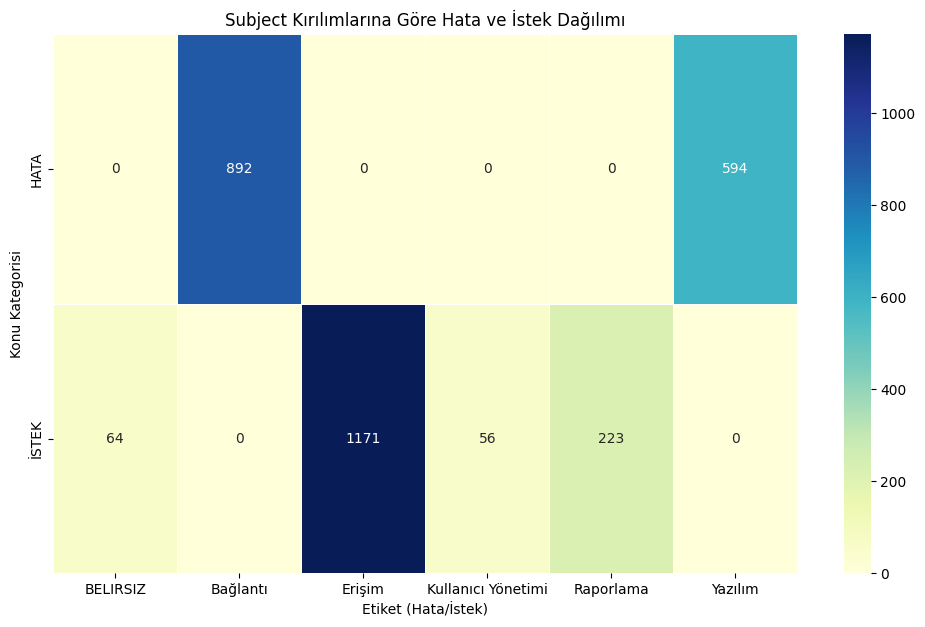

In [7]:
import matplotlib.pyplot as plt
import seaborn as sns

# Filtreleme: Sadece 'HATA' ve 'İSTEK'
filtered_df = df[df['label'].isin(['HATA', 'İSTEK'])]

# 'label' ve 'regex_subject'a göre gruplandır ve say
subject_label_counts = filtered_df.groupby(['label', 'regex_subject']).size().unstack(fill_value=0)

# Grafik çizimi
plt.figure(figsize=(12, 7))
sns.heatmap(subject_label_counts, annot=True, fmt="d", cmap="YlGnBu", linewidths=.5)
plt.title('Subject Kırılımlarına Göre Hata ve İstek Dağılımı')
plt.xlabel('Etiket (Hata/İstek)')
plt.ylabel('Konu Kategorisi')
plt.show()


Belirsiz kategorilerin dağılımı. Bu örnekte verilerin tamamı Hata ve İstek olarak iki ana sınıfa ayrıldığı için "Belirsiz" etiketi bulunmuyor. İstek ana grubu içinde 64 girişin kategorisi mevcut regex anahtar kelimeleri ile belirlenememiştir.






LLM'e Gidecek Verinin Belirlenmesi

In [8]:
# 1. LLM'e gidecek veri setini ayırma
llm_dataset = df[df["needs_llm"] == True].copy()

# 2. Özet Bilgi
print(f"Toplam Veri Sayısı: {len(df)}")
print(f"Otomatik Çözülen (Regex): {len(df) - len(llm_dataset)}")
print(f"Yapay Zekaya Gönderilecek: {len(llm_dataset)}")

# 3. LLM'e gidecek örnek birkaç vaka
print("\n--- AI Analizine Gönderilen Vakalar ---")
if not llm_dataset.empty:
    print(llm_dataset[['id', 'body']].head())
else:
    print("Tüm veriler regex ile başarıyla sınıflandırıldı!")

Toplam Veri Sayısı: 3000
Otomatik Çözülen (Regex): 2936
Yapay Zekaya Gönderilecek: 64

--- AI Analizine Gönderilen Vakalar ---
      id                                               body
4    156  Selamlar,\n\nEkibe yeni bir arkadaşımız katıld...
87   377  Selamlar,\n\nEkibe yeni bir arkadaşımız katıld...
111  553  Selamlar,\n\nEkibe yeni bir arkadaşımız katıld...
163  380  Selamlar,\n\nEkibe yeni bir arkadaşımız katıld...
177  251  Selamlar,\n\nEkibe yeni bir arkadaşımız katıld...


**LLM Prompt Mühendisliği**

In [11]:
import google.generativeai as genai
from google.colab import userdata
import time
import pandas as pd
from tqdm import tqdm

# 1. API Yapılandırması
try:
    api_key = userdata.get('GOOGLE_API_KEY')
    genai.configure(api_key=api_key)
    model = genai.GenerativeModel('gemini-2.5-flash')
    print("API Bağlantısı Başarılı!")
except Exception as e:
    print(f"API Hatası: {e}. Lütfen Secrets kısmını kontrol et.")

# 2. Sınıflandırma Fonksiyonu ve Prompt
def ai_siniflandir(metin):

    prompt = f"""
Sen bir IT Help Desk sınıflandırma motorusun.
Girdi: tek bir e-posta/talep metni.

Görevlerin:
1) Talebi önce tip olarak sınıflandır:
   - "HATA": arıza/bozulma/çalışmıyor/ulaşılamıyor/problem vb.
   - "ISTEK": kurulum/ekleme/talep/yetki isteme/yeni kullanıcı açma vb.
   - "BELIRSIZ": emin değilsen

2) Talebi aşağıdaki kategorilerden TAM OLARAK BİRİNE ata:
   - "Bağlantı"
   - "Donanım"
   - "Erişim"
   - "Yazılım"
   - "Kullanıcı Yönetimi"
   - "Raporlama"

Kurallar:
- Sadece bu kategorileri kullan.
- Sadece kategori adını yaz.
- Metinden çıkarım yap; ama kanıt zayıfsa confidence düşür.
- Çıktı SADECE geçerli JSON olsun (açıklama yok).

Çıktı şeması:
{{
  "final_label": "HATA|ISTEK|BELIRSIZ",
  "final_category": "Bağlantı|Donanım|Erişim|Yazılım|Kullanıcı Yönetimi|Raporlama",
  "confidence": 0.0-1.0,
}}

Metin:
<<<{metin}>>>
"""

    while True:
        try:
            # API isteği [cite: 15]
            response = model.generate_content(prompt)

            # Başarılı cevap alındıysa sonucu dön
            if response and response.text:
                return response.text.strip()
            return "BELIRSIZ"

        except Exception as e:
            hata_mesaji = str(e)

            # Durum 1: Kota Limit Hatası (429)
            if "429" in hata_mesaji:
                print("\n[Kota Limiti] Ücretsiz katman sınırı aşıldı. 60 saniye zorunlu mola...")
                time.sleep(60)
                continue # Tekrar dene

            # Durum 2: Zaman Aşımı veya Bağlantı Hatası (Timeout)
            elif "timeout" in hata_mesaji.lower() or "500" in hata_mesaji:
                print(f"\n[Bağlantı Hatası] Sunucu yanıt vermedi, 15 saniye sonra tekrar deneniyor: {e}")
                time.sleep(15)
                continue # Tekrar dene

            # Durum 3: Diğer Beklenmedik Hatalar
            else:
                print(f"\n[Beklenmedik Hata] {e}")
                return "HATA"

# 2. Tek Tek Gönderme ve Bekleme Süresi
mask = df['needs_llm'] == True
indices = df[mask].index

print(f"Toplam {len(indices)} satır AI ile işlenecek. Lütfen bekleyin...")

# tqdm ile görsel bir ilerleme çubuğu oluşturma
for idx in tqdm(indices):
    body_content = df.at[idx, 'body']

    # Sınıflandırma işlemini yap
    sonuc = ai_siniflandir(body_content)
    df.at[idx, 'label'] = sonuc

    # Güvenli kalmak için her istek sonrası 13 saniye bekleme
    time.sleep(13)

print("\n--- İşlem Başarıyla Tamamlandı! ---")
print(df[['body', 'label']].head())

/usr/local/lib/python3.12/dist-packages/google/colab/_import_hooks/_hook_injector.py:55: FutureWarning: 

All support for the `google.generativeai` package has ended. It will no longer be receiving 
updates or bug fixes. Please switch to the `google.genai` package as soon as possible.
See README for more details:

https://github.com/google-gemini/deprecated-generative-ai-python/blob/main/README.md

  loader.exec_module(module)


API Bağlantısı Başarılı!
Toplam 64 satır AI ile işlenecek. Lütfen bekleyin...


100%|██████████| 64/64 [25:12<00:00, 23.63s/it]


--- İşlem Başarıyla Tamamlandı! ---
                                                body  \
0  Merhaba,\n\nİK portalına ve ERP sistemine girm...   
1  Merhaba,\n\nİK portalına ve ERP sistemine girm...   
2  Selamlar,\n\nVPN'e bağlanmaya çalışırken sürek...   
3  Merhaba,\n\nSAP'a girmeye çalıştığımda sunucu ...   
4  Selamlar,\n\nEkibe yeni bir arkadaşımız katıld...   

                                               label  
0                                               HATA  
1                                               HATA  
2                                               HATA  
3                                               HATA  
4  ```json\n{\n  "final_label": "ISTEK",\n  "fina...  


64 veri için başarıyla kategori belirlendi.

In [13]:
# Raporlama ve Excel Olarak Kaydetme

output_file_path = '/content/drive/MyDrive/Colab Notebooks/v1_f_IT_Department_Sonuclari.xlsx'

try:
    # index=False parametresi satır numaralarının kaydedilmesini önler
    df.to_excel(output_file_path, index=False)

    print(f"\n✅ İşlem başarıyla tamamlandı!")
    print(f"📁 Dosya kaydedildi: {output_file_path}")

    # Sınıflandırma dağılımı kontrolü
    print("\n📊 Nihai Kategori Dağılımı:")
    print(df['label'].value_counts())

except Exception as e:
    print(f"❌ Dosya kaydedilirken bir hata oluştu: {e}")


✅ İşlem başarıyla tamamlandı!
📁 Dosya kaydedildi: /content/drive/MyDrive/Colab Notebooks/v1_f_IT_Department_Sonuclari.xlsx

📊 Nihai Kategori Dağılımı:
label
HATA                                                                                                              1486
İSTEK                                                                                                             1450
```json\n{\n  "final_label": "ISTEK",\n  "final_category": "Erişim",\n  "confidence": 0.95\n}\n```                  19
```json\n{\n  "final_label": "ISTEK",\n  "final_category": "Erişim",\n  "confidence": 0.9\n}\n```                   13
```json\n{\n  "final_label": "ISTEK",\n  "final_category": "Kullanıcı Yönetimi",\n  "confidence": 0.95\n}\n```      10
```json\n{\n  "final_label": "ISTEK",\n  "final_category": "Erişim",\n  "confidence": 0.98\n}\n```                   5
```json\n{\n  "final_label": "ISTEK",\n  "final_category": "Erişim",\n  "confidence": 1.0\n}\n```                    4
```json\n

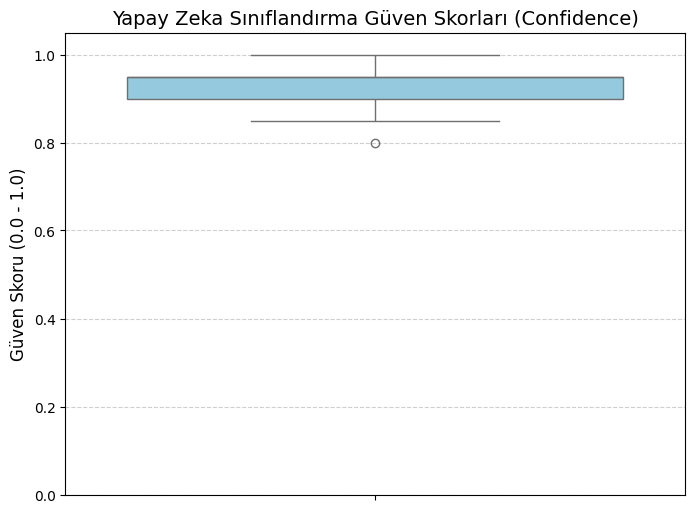


Güven Skoru İstatistikleri:
count    64.000000
mean      0.935625
std       0.038250
min       0.800000
25%       0.900000
50%       0.950000
75%       0.950000
max       1.000000
Name: confidence_score, dtype: float64


In [16]:
import json
import matplotlib.pyplot as plt
import seaborn as sns

# 1. JSON verisinden 'confidence' değerlerini ayıklama
def confidence_ayikla(label_text):
    try:
          if isinstance(label_text, str) and label_text.startswith("```json"):
            label_text = label_text.replace("```json", "").replace("```", "").strip()
        data = json.loads(label_text)
        return float(data.get('confidence', 0))
    except (json.JSONDecodeError, AttributeError):
        return None
    except Exception as e:
        print(f"Error parsing confidence: {e} for text: {label_text}")
        return None

# Sadece AI tarafından işlenen satırlar
llm_results = df[df['needs_llm'] == True].copy()
llm_results['confidence_score'] = llm_results['label'].apply(confidence_ayikla)

# NaN değerleri içeren satırları filtrele
llm_results_cleaned = llm_results.dropna(subset=['confidence_score'])

# 2. Boxplot Çizimi
plt.figure(figsize=(8, 6))
sns.boxplot(y=llm_results_cleaned['confidence_score'], color='skyblue')

# Grafik başlıkları ve ayarları
plt.title('Yapay Zeka Sınıflandırma Güven Skorları (Confidence)', fontsize=14)
plt.ylabel('Güven Skoru (0.0 - 1.0)', fontsize=12)
plt.ylim(0, 1.05) # Y ekseni
plt.grid(axis='y', linestyle='--', alpha=0.6)

plt.show()

# İstatistiksel özet
print("\nGüven Skoru İstatistikleri:")
print(llm_results_cleaned['confidence_score'].describe())

In [24]:
import pandas as pd
import json
import collections
import re
import os

# 1. Dinamik Veri Kaynağı Kontrolü
# Eğer hafızada güncel 'df' varsa onu kullanır, yoksa Drive'daki en son dosyayı yükler.
file_path = '/content/drive/MyDrive/Colab Notebooks/v1_f_IT_Department_Sonuclari.xlsx'

if 'df' in locals() and not df[df['needs_llm'] == True]['label'].isnull().all():
    print("✅ Mevcut çalışma verisi (DataFrame) kullanılıyor.")
    llm_df = df[df['needs_llm'] == True].copy()
elif os.path.exists(file_path):
    print("📂 Drive'daki güncel sonuç dosyası yükleniyor...")
    df = pd.read_excel(file_path)
    llm_df = df[df['needs_llm'] == True].copy()
else:
    print("⚠️ Analiz edilecek LLM verisi bulunamadı!")
    llm_df = pd.DataFrame()

# 2. JSON Formatındaki Label Verisini Çözme
def kategori_ayikla(json_text):
    if pd.isna(json_text): return "BELIRSIZ"

    # 1. Markdown bloklarını temizle (```json ... ``` kısmını atar)
    clean_text = re.sub(r'```json\s*|```', '', str(json_text)).strip()

    try:
        data = json.loads(clean_text)
        # 2. Kategori ismini al ve etrafındaki boşlukları temizle
        return str(data.get('final_category', 'BELIRSIZ')).strip()
    except Exception as e:
        # Eğer hala hata varsa, metnin içinden anahtar kelimeyi bulmaya çalışalım
        for k in ["Bağlantı", "Donanım", "Erişim", "Yazılım", "Kullanıcı Yönetimi", "Raporlama"]:
            if k.lower() in clean_text.lower():
                return k
        return "HATA (JSON OKUNAMADI)"

if not llm_df.empty:
    llm_df['temiz_kategori'] = llm_df['label'].apply(kategori_ayikla)

    # 3. Kelime-Kategori Korelasyonu ve Frekans Analizi
    # Sadece metin içeren satırları alalım
    kategoriler = ["Bağlantı", "Donanım", "Erişim", "Yazılım", "Kullanıcı Yönetimi", "Raporlama"]

    print("\n--- Regex Optimizasyonu İçin Kelime Analizi ---")

    for kat in kategoriler:
        # Belirli bir kategoriye ait metinleri filtrele
        kat_data = llm_df[llm_df['temiz_kategori'] == kat]

        if len(kat_data) == 0:
            continue

        # Body metinlerini temizle ve kelimelere böl
        all_words = []
        for text in kat_data['body'].astype(str):
            # 3 harften büyük Türkçe/İngilizce karakterli kelimeleri al
            words = re.findall(r"[a-zA-ZçğıöşüÇĞİÖŞÜ]{4,}", text.lower())
            all_words.extend(words)

        # En sık geçen kelimeler (Korelasyon adayları)
        counts = collections.Counter(all_words)
        common = counts.most_common(12)

        # Bu kelimeler her kategoride çıkabilir.
        stop_words = {'merhaba', 'merhabalar', 'selam','selamlar', 'teşekkür','teşekkürler', 'lütfen', 'yardım', 'rica', 'günler', 'iyi'}
        clean_common = [w for w in common if w[0] not in stop_words][:8]

        print(f"\n📂 KATEGORİ: {kat.upper()} ({len(kat_data)} Örnek)")
        print(f"🔗 Güçlü İlişkili Kelimeler: {', '.join([word for word, count in clean_common])}")
        print("-" * 100)

✅ Mevcut çalışma verisi (DataFrame) kullanılıyor.

--- Regex Optimizasyonu İçin Kelime Analizi ---

📂 KATEGORİ: BAĞLANTI (8 Örnek)
🔗 Güçlü İlişkili Kelimeler: için, ekibe, yeni, arkadaşımız, katıldı, evden, çalışabilmesi, bilgisayarına
----------------------------------------

📂 KATEGORİ: ERIŞIM (42 Örnek)
🔗 Güçlü İlişkili Kelimeler: için, ekibe, yeni, arkadaşımız, katıldı, evden, çalışabilmesi, bilgisayarına
----------------------------------------

📂 KATEGORİ: KULLANICI YÖNETIMI (14 Örnek)
🔗 Güçlü İlişkili Kelimeler: için, ekibe, yeni, arkadaşımız, katıldı, evden, çalışabilmesi, bilgisayarına
----------------------------------------
